# 🎯 Stage 11 — Risk Parity Portfolio Construction  

Traditional portfolio optimization relies heavily on expected return forecasts and covariance matrix inversion.

Risk Parity follows a different principle:

> Allocate capital so that each asset contributes equally to total portfolio risk.

Instead of predicting which assets will outperform, we focus on how total portfolio volatility is distributed.

---

## 🧩 Objective  

This notebook constructs and analyzes an **Equal Risk Contribution (ERC)** portfolio.

We will:

- Decompose total portfolio volatility into individual asset risk contributions  
- Construct an Equal Risk Contribution portfolio  
- Solve the nonlinear optimization problem enforcing equal risk allocation  
- Compare against:
  - Equal Weight portfolio  
  - Minimum Variance portfolio  
  - Maximum Sharpe portfolio  
- Evaluate diversification and stability properties  

---

## ⚙️ Mathematical Framework  

Let:

$[
\Sigma = \text{Covariance matrix of asset returns}
$]

$[
w = \text{Portfolio weight vector}
$]

### Portfolio Variance

$[
\sigma_p^2 = w^\top \Sigma w
$]

### Portfolio Volatility

$[
\sigma_p = \sqrt{w^\top \Sigma w}
$]

### Marginal Risk Contribution (MRC)

$[
\text{MRC}_i = \frac{\partial \sigma_p}{\partial w_i}
$]

### Total Risk Contribution (RC)

$[
\text{RC}_i = w_i (\Sigma w)_i
$]

### Risk Parity Condition

$[
\text{RC}_1 = \text{RC}_2 = \dots = \text{RC}_n
$]

We solve:

$[
\min_{w} \sum_{i=1}^{n} \left( \text{RC}_i - \frac{\sigma_p}{n} \right)^2
$]

Subject to:

$[
\sum_{i=1}^{n} w_i = 1, \quad w_i \ge 0
$]

---

## 💡 Why It Matters  

Mean–variance optimization can produce unstable or extreme weights when covariance estimates are noisy.

Risk Parity shifts the emphasis from return forecasting to balanced risk allocation, often leading to:

- Improved diversification  
- Lower concentration risk  
- Greater weight stability  
- Reduced sensitivity to estimation error  

This reframes portfolio construction from:

$[
\text{Maximize expected return per unit risk}
$]

to:

$[
\text{Distribute total risk evenly across assets}
$]

---

## 📊 Dataset & Tools  

**Assets:** AAPL, MSFT, GOOG, AMZN, TSLA, JNJ, JPM, NVDA  
**Period:** 2020 – 2025  

**Libraries:** NumPy, Pandas, Matplotlib, SciPy  

---

## 🚀 Workflow  

1. Fetch historical price data  
2. Compute returns and covariance matrix  
3. Define portfolio volatility function  
4. Compute marginal and total risk contributions  
5. Solve the Equal Risk Contribution optimization problem  
6. Compare performance with alternative allocations  
7. Visualize portfolio weights and risk contributions  


/tmp/ipython-input-4138387136.py:24: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(assets, start=start, end=end)["Close"]
[*********************100%***********************]  8 of 8 completed



📊 Performance Comparison

      Portfolio  Return  Volatility  Sharpe
0  Equal Weight  0.3494      0.2782  1.2558
1  Min Variance  0.0954      0.1821  0.5238
2    Max Sharpe  0.7371      0.4853  1.5187
3   Risk Parity  0.2619      0.2325  1.1262


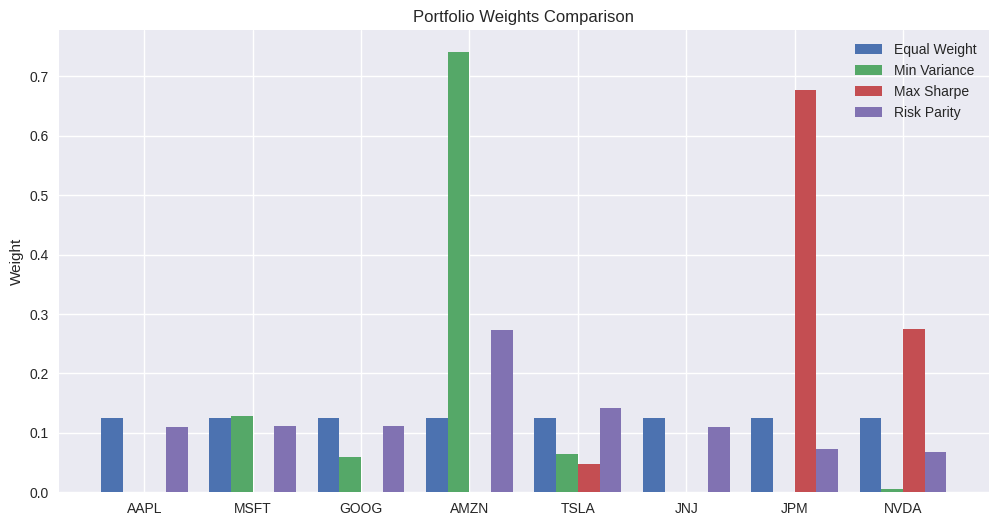

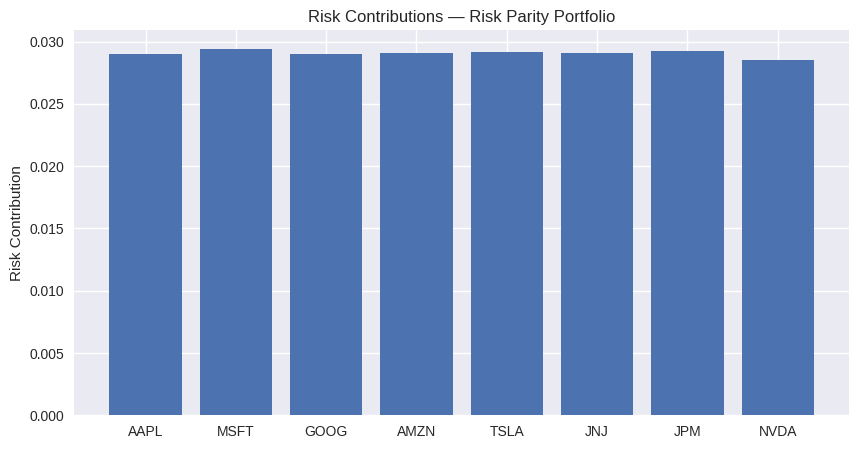

In [1]:

!pip install yfinance --quiet

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from scipy.optimize import minimize

plt.style.use("seaborn-v0_8")

# -------------------------------
# 1️ Fetch Data
# -------------------------------

assets = ["AAPL","MSFT","GOOG","AMZN","TSLA","JNJ","JPM","NVDA"]
start = "2020-01-01"
end   = "2025-01-01"

data = yf.download(assets, start=start, end=end)["Close"]
returns = data.pct_change().dropna()

cov = returns.cov() * 252
mean_returns = returns.mean() * 252
n = len(assets)

# -------------------------------
# 2️ Helper Functions
# -------------------------------

def portfolio_vol(w, cov):
    return np.sqrt(w.T @ cov @ w)

def portfolio_return(w, mean_returns):
    return w @ mean_returns

def risk_contribution(w, cov):
    sigma_p = portfolio_vol(w, cov)
    marginal = cov @ w
    return w * marginal / sigma_p

# -------------------------------
# 3️ Equal Weight
# -------------------------------

w_eq = np.ones(n) / n

# -------------------------------
# 4️ Minimum Variance
# -------------------------------

def min_var_objective(w):
    return portfolio_vol(w, cov)

constraints = ({'type': 'eq', 'fun': lambda w: np.sum(w) - 1})
bounds = tuple((0,1) for _ in range(n))
w0 = np.ones(n)/n

w_minvar = minimize(min_var_objective, w0,
                    method='SLSQP',
                    bounds=bounds,
                    constraints=constraints).x

# -------------------------------
# 5️ Maximum Sharpe
# -------------------------------

def neg_sharpe(w):
    return - portfolio_return(w, mean_returns) / portfolio_vol(w, cov)

w_maxsharpe = minimize(neg_sharpe, w0,
                       method='SLSQP',
                       bounds=bounds,
                       constraints=constraints).x

# -------------------------------
# 6️ Risk Parity (ERC)
# -------------------------------

def erc_objective(w):
    rc = risk_contribution(w, cov)
    return np.sum((rc - np.mean(rc))**2)

w_erc = minimize(erc_objective, w0,
                 method='SLSQP',
                 bounds=bounds,
                 constraints=constraints).x

# -------------------------------
# 7️ Performance Comparison
# -------------------------------

portfolios = {
    "Equal Weight": w_eq,
    "Min Variance": w_minvar,
    "Max Sharpe": w_maxsharpe,
    "Risk Parity": w_erc
}

results = []

for name, w in portfolios.items():
    ret = portfolio_return(w, mean_returns)
    vol = portfolio_vol(w, cov)
    sharpe = ret / vol
    results.append([name, ret, vol, sharpe])

results_df = pd.DataFrame(results,
                          columns=["Portfolio","Return","Volatility","Sharpe"])

print("\n📊 Performance Comparison\n")
print(results_df.round(4))

# -------------------------------
# 8️ Plot Weights
# -------------------------------

fig, ax = plt.subplots(figsize=(12,6))
width = 0.2
x = np.arange(n)

for i, (name, w) in enumerate(portfolios.items()):
    ax.bar(x + i*width, w, width, label=name)

ax.set_xticks(x + width*1.5)
ax.set_xticklabels(assets)
ax.set_ylabel("Weight")
ax.set_title("Portfolio Weights Comparison")
ax.legend()
plt.show()

# -------------------------------
# 9️ Risk Contribution Plot (ERC)
# -------------------------------

rc_erc = risk_contribution(w_erc, cov)

plt.figure(figsize=(10,5))
plt.bar(assets, rc_erc)
plt.title("Risk Contributions — Risk Parity Portfolio")
plt.ylabel("Risk Contribution")
plt.show()


## 📊 Interpretation — Performance Comparison

The annualized performance metrics reveal distinct structural behaviors across portfolio construction methods.

### 🔹 Maximum Sharpe Portfolio
- Highest return (0.7371)  
- Highest volatility (0.4853)  
- Highest Sharpe ratio (1.5187)  

This portfolio aggressively concentrates capital in assets with strong in-sample performance. While it maximizes risk-adjusted return mathematically, it also carries substantial concentration risk and volatility.

---

### 🔹 Minimum Variance Portfolio
- Lowest volatility (0.1821)  
- Lowest return (0.0954)  
- Weak Sharpe ratio (0.5238)  

This allocation prioritizes stability over growth. It reduces risk effectively but sacrifices return potential, making it conservative but capital-inefficient.

---

### 🔹 Equal Weight Portfolio
- Balanced return (0.3494)  
- Moderate volatility (0.2782)  
- Solid Sharpe ratio (1.2558)  

Equal Weight serves as a robust benchmark. It avoids concentration and performs competitively without relying on optimization.

---

### 🔹 Risk Parity Portfolio
- Return (0.2619) lower than Equal Weight  
- Volatility (0.2325) lower than Equal Weight  
- Sharpe ratio (1.1262) stable and competitive  

Risk Parity reduces volatility relative to Equal Weight while maintaining reasonable risk-adjusted performance. Its structure ensures that no single asset dominates total portfolio risk.

---

### 🧠 Structural Insight

The results illustrate the core tradeoff in portfolio construction:

$$
\text{Return Maximization} \quad \leftrightarrow \quad \text{Risk Control}
$$

- Maximum Sharpe maximizes efficiency but increases fragility.
- Minimum Variance minimizes volatility but limits growth.
- Equal Weight balances simplicity and diversification.
- Risk Parity redistributes risk evenly, improving structural stability.

This comparison highlights how allocation philosophy directly shapes performance characteristics.


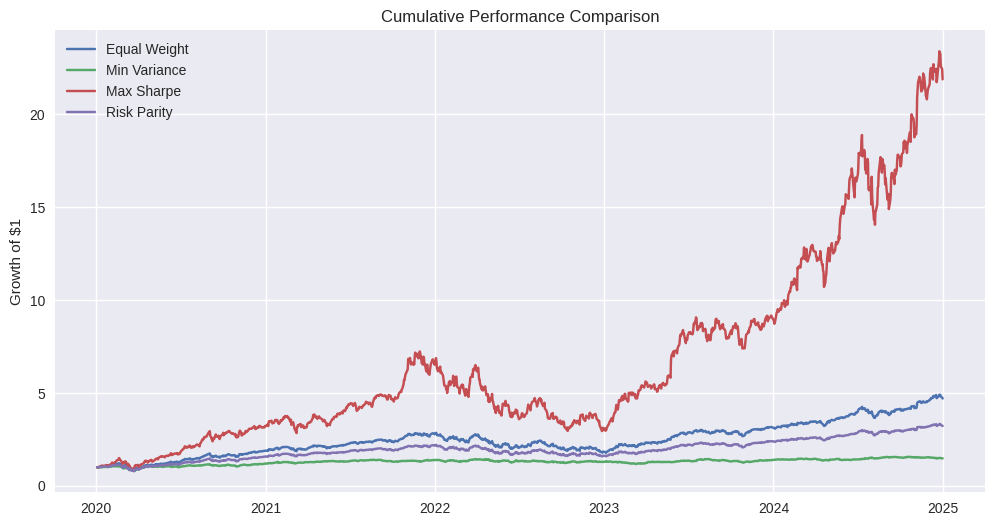


📉 Performance Including Drawdown

      Portfolio  Return  Volatility  Sharpe  Max Drawdown
0  Equal Weight  0.3494      0.2782  1.2558       -0.3757
1  Min Variance  0.0954      0.1821  0.5238       -0.2588
2    Max Sharpe  0.7371      0.4853  1.5187       -0.5924
3   Risk Parity  0.2619      0.2325  1.1262       -0.3007


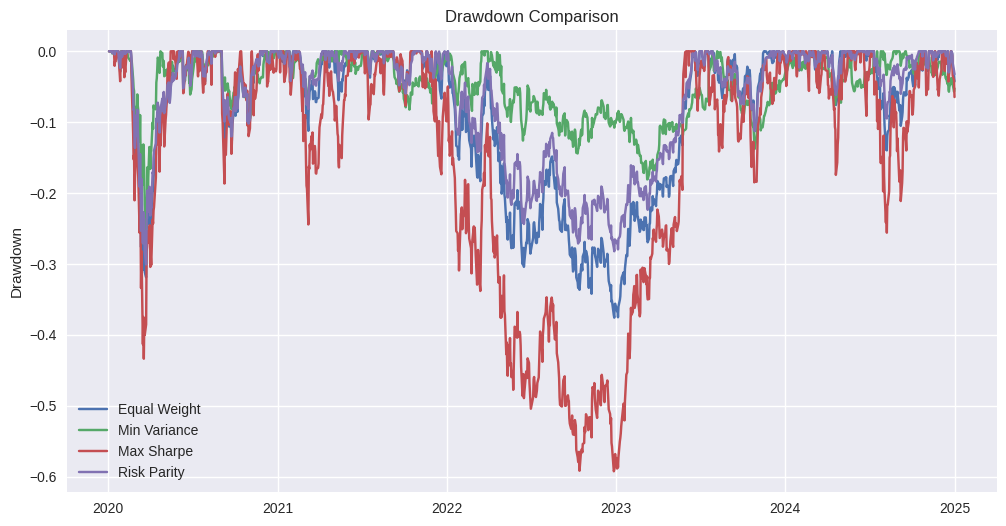

In [2]:
# =========================================
# 🔹 Cumulative Performance & Drawdowns
# =========================================

# Daily portfolio returns
portfolio_daily_returns = {}

for name, w in portfolios.items():
    portfolio_daily_returns[name] = returns @ w

portfolio_daily_returns = pd.DataFrame(portfolio_daily_returns)

# Cumulative Returns
cumulative_returns = (1 + portfolio_daily_returns).cumprod()

plt.figure(figsize=(12,6))
for col in cumulative_returns.columns:
    plt.plot(cumulative_returns[col], label=col)

plt.title("Cumulative Performance Comparison")
plt.ylabel("Growth of $1")
plt.legend()
plt.show()


# =========================================
# 🔹 Maximum Drawdown Function
# =========================================

def max_drawdown(series):
    cumulative = (1 + series).cumprod()
    peak = cumulative.cummax()
    drawdown = (cumulative - peak) / peak
    return drawdown.min()

# Compute Max Drawdowns
mdd_results = []

for name in portfolio_daily_returns.columns:
    mdd = max_drawdown(portfolio_daily_returns[name])
    mdd_results.append(mdd)

results_df["Max Drawdown"] = mdd_results

print("\n📉 Performance Including Drawdown\n")
print(results_df.round(4))


# =========================================
# 🔹 Plot Drawdowns
# =========================================

plt.figure(figsize=(12,6))

for col in portfolio_daily_returns.columns:
    cumulative = (1 + portfolio_daily_returns[col]).cumprod()
    peak = cumulative.cummax()
    drawdown = (cumulative - peak) / peak
    plt.plot(drawdown, label=col)

plt.title("Drawdown Comparison")
plt.ylabel("Drawdown")
plt.legend()
plt.show()


In [3]:
# =========================================
# 🔹 Save Figures and Zip Them
# =========================================

import os
import zipfile

# Create directory
folder_name = "risk_parity_outputs"
os.makedirs(folder_name, exist_ok=True)

# 1️⃣ Save Cumulative Performance
plt.figure(figsize=(12,6))
for col in cumulative_returns.columns:
    plt.plot(cumulative_returns[col], label=col)
plt.title("Cumulative Performance Comparison")
plt.ylabel("Growth of $1")
plt.legend()
cum_path = os.path.join(folder_name, "cumulative_performance.png")
plt.savefig(cum_path, dpi=300, bbox_inches="tight")
plt.close()

# 2️⃣ Save Drawdown Plot
plt.figure(figsize=(12,6))
for col in portfolio_daily_returns.columns:
    cumulative = (1 + portfolio_daily_returns[col]).cumprod()
    peak = cumulative.cummax()
    drawdown = (cumulative - peak) / peak
    plt.plot(drawdown, label=col)
plt.title("Drawdown Comparison")
plt.ylabel("Drawdown")
plt.legend()
dd_path = os.path.join(folder_name, "drawdown_comparison.png")
plt.savefig(dd_path, dpi=300, bbox_inches="tight")
plt.close()

# 3️⃣ Save Risk Contribution Plot
plt.figure(figsize=(10,5))
plt.bar(assets, rc_erc)
plt.title("Risk Contributions — Risk Parity Portfolio")
plt.ylabel("Risk Contribution")
rc_path = os.path.join(folder_name, "risk_contributions.png")
plt.savefig(rc_path, dpi=300, bbox_inches="tight")
plt.close()

# -----------------------------------------
# Zip Everything
# -----------------------------------------

zip_filename = "risk_parity_outputs.zip"

with zipfile.ZipFile(zip_filename, "w") as z:
    for file in os.listdir(folder_name):
        z.write(os.path.join(folder_name, file),
                arcname=file)

print("✅ Images saved and zipped successfully.")

# -----------------------------------------
# Download (Colab)
# -----------------------------------------

from google.colab import files
files.download(zip_filename)


✅ Images saved and zipped successfully.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 📉 Drawdown Interpretation & Key Insights

### 🔎 Drawdown Comparison

The drawdown analysis reveals clear structural differences between allocation methods:

- **Maximum Sharpe Portfolio**
  - Achieves the highest cumulative return.
  - Exhibits the deepest drawdown (~ -59%).
  - Concentration risk amplifies downside during market stress.

- **Minimum Variance Portfolio**
  - Lowest volatility.
  - Shallowest drawdowns (~ -26%).
  - Capital-efficient during downturns but sacrifices return potential.

- **Equal Weight Portfolio**
  - Balanced exposure across assets.
  - Moderate drawdown (~ -38%).
  - Serves as a strong, simple benchmark.

- **Risk Parity (ERC) Portfolio**
  - Drawdown (~ -30%) significantly lower than Equal Weight.
  - Avoids extreme concentration.
  - Demonstrates smoother risk distribution across assets.

### 🧠 Structural Interpretation

The results highlight a core tradeoff in portfolio construction:

$$
\text{Return Maximization} \quad \leftrightarrow \quad \text{Risk Stability}
$$

The Maximum Sharpe portfolio optimizes expected performance but is fragile under stress due to weight concentration.

Risk Parity reallocates capital such that:

$$
\text{RC}_1 = \text{RC}_2 = \dots = \text{RC}_n
$$

This equalization of risk contributions reduces concentration risk and improves downside resilience, even if it sacrifices peak upside.

### 🎯 Skills Developed in This Notebook

This project strengthened:

- Portfolio volatility decomposition  
- Marginal and total risk contribution analysis  
- Nonlinear constrained optimization (SLSQP)  
- Practical implementation of Equal Risk Contribution  
- Performance evaluation (Sharpe, volatility, drawdown)  
- Visual risk diagnostics and portfolio comparison  

More importantly, it reinforced a structural insight:

> Optimization can maximize returns, but risk allocation determines survivability.

Risk Parity provides a framework for balancing exposure across assets without relying on unstable return forecasts.

---

This completes the Risk Parity portfolio construction framework.

## 🔍 Personal Reflection — Understanding Risk Parity

Before implementing Risk Parity, I viewed portfolio construction primarily through the lens of return optimization — maximizing Sharpe ratio or minimizing variance.

This notebook shifted that perspective.

Risk Parity reframes the problem:

$$
\text{Instead of optimizing returns, balance risk contributions.}
$$

Through implementation, I observed that:

- Return-maximizing portfolios tend to concentrate heavily in a few assets.
- Small changes in covariance can produce extreme weight shifts.
- Equal Risk Contribution enforces structural balance rather than chasing performance.

The most important realization was that portfolio construction is not only about efficiency — it is about robustness.

Risk Parity does not attempt to forecast which asset will outperform.  
Instead, it ensures that no single asset dominates the portfolio’s risk profile:

$$
\text{RC}_i = \frac{\sigma_p}{n}
$$

This constraint produces smoother drawdowns and more stable allocations.

Technically, this project strengthened my understanding of:

- Volatility decomposition
- Sensitivity of optimization to estimation error
- Constrained nonlinear optimization
- The trade-off between concentration and stability

Conceptually, it reinforced a broader insight:

Maximizing expected return is only one dimension of portfolio design.  
Managing how risk is distributed is equally fundamental.

Risk Parity represents a shift from performance-seeking optimization to structure-aware allocation.
